# Proyek Klasifikasi Gambar: Fruit Classification

**Nama:** Eko Andri Prasetyo

**Email:** eko.andri@prasetyo.co

**ID Dicoding:** ekoandriprasetyo

---

## Deskripsi Proyek
Proyek ini mengklasifikasikan gambar buah-buahan menggunakan Convolutional Neural Network (CNN) dengan arsitektur Sequential.

## 1. Import Library

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
from sklearn.model_selection import train_test_split
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## 2. Download Dataset dari Kaggle

In [2]:
# Install kaggle
!pip install -q kaggle

In [3]:
# Upload kaggle.json
# Dapatkan dari: Kaggle > Profile > Settings > API > Create New Token
from google.colab import files
print("Upload file kaggle.json dari komputer Anda:")
files.upload()

Upload file kaggle.json dari komputer Anda:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ekoandriprasetyo","key":"13559fb8a406c7cf0dca2892ece2ad34"}'}

In [4]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle credentials berhasil di-setup!")

✅ Kaggle credentials berhasil di-setup!


In [5]:
# Download Fruits 360 Dataset
!kaggle datasets download -d moltean/fruits
print("\n✅ Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 4.89G/4.90G [01:08<00:00, 303MB/s]
100% 4.90G/4.90G [01:08<00:00, 77.0MB/s]

✅ Download selesai!


In [6]:
# Extract dataset
import zipfile

with zipfile.ZipFile('fruits.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/fruits_dataset')

print("✅ Dataset berhasil diekstrak!")

# Lihat struktur
!ls /content/fruits_dataset/

✅ Dataset berhasil diekstrak!
fruits-360_100x100	   fruits-360_dataset_meta  fruits-360_original-size
fruits-360_3-body-problem  fruits-360_multi


## 3. Konfigurasi Path Dataset

In [7]:
# PATH YANG BENAR untuk Fruits 360 Dataset
SOURCE_DIR = '/content/fruits_dataset/fruits-360_original-size/fruits-360-original-size/Training'

# Path alternatif jika yang atas tidak ada
if not os.path.exists(SOURCE_DIR):
    SOURCE_DIR = '/content/fruits_dataset/fruits-360_100x100/fruits-360/Training'

if not os.path.exists(SOURCE_DIR):
    # Cari secara otomatis
    for root, dirs, files in os.walk('/content/fruits_dataset'):
        if 'Training' in dirs:
            potential_path = os.path.join(root, 'Training')
            if len(os.listdir(potential_path)) > 10:
                SOURCE_DIR = potential_path
                break

print(f"✅ SOURCE_DIR: {SOURCE_DIR}")
print(f"   Exists: {os.path.exists(SOURCE_DIR)}")

✅ SOURCE_DIR: /content/fruits_dataset/fruits-360_original-size/fruits-360-original-size/Training
   Exists: True


In [8]:
# Lihat kelas yang tersedia
print("=" * 60)
print("KELAS YANG TERSEDIA")
print("=" * 60)

available_classes = sorted(os.listdir(SOURCE_DIR))
print(f"\nTotal kelas: {len(available_classes)}\n")

for i, cls in enumerate(available_classes):
    class_path = os.path.join(SOURCE_DIR, cls)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"  {i+1:3}. {cls} ({count} gambar)")

KELAS YANG TERSEDIA

Total kelas: 121

    1. Apple 10 (465 gambar)
    2. Apple 11 (287 gambar)
    3. Apple 12 (310 gambar)
    4. Apple 13 (465 gambar)
    5. Apple 14 (310 gambar)
    6. Apple 17 (489 gambar)
    7. Apple 18 (486 gambar)
    8. Apple 19 (486 gambar)
    9. Apple 5 (294 gambar)
   10. Apple 7 (462 gambar)
   11. Apple 8 (458 gambar)
   12. Apple 9 (463 gambar)
   13. Apple Core 1 (314 gambar)
   14. Apple Red Yellow 2 (453 gambar)
   15. Apple worm 1 (465 gambar)
   16. Avocado Black 1 (468 gambar)
   17. Avocado Black 2 (492 gambar)
   18. Avocado Green 1 (468 gambar)
   19. Banana 3 (154 gambar)
   20. Banana 4 (169 gambar)
   21. Beans 1 (155 gambar)
   22. Blackberrie 1 (300 gambar)
   23. Blackberrie 2 (150 gambar)
   24. Blackberrie half rippen 1 (300 gambar)
   25. Blackberrie not rippen 1 (463 gambar)
   26. Cabbage red 1 (99 gambar)
   27. Cactus fruit green 1 (465 gambar)
   28. Cactus fruit red 1 (475 gambar)
   29. Caju seed 1 (151 gambar)
   30. Cherimo

## 4. Split Dataset (Train, Validation, Test)

In [9]:
# ============================================
# PILIH KELAS YANG INGIN DIGUNAKAN
# Sesuaikan dengan nama kelas yang tersedia!
# Gunakan nama PERSIS seperti yang muncul di output cell sebelumnya
# ============================================

# Ambil 5 kelas pertama secara otomatis dari dataset
available_classes = sorted([d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))])
CLASSES = available_classes[:5]  # Ambil 5 kelas pertama

# Atau tentukan manual (uncomment dan sesuaikan nama):
# CLASSES = ['Apple Braeburn', 'Banana', 'Orange']

# Path output
DATASET_DIR = '/content/dataset'
TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
VAL_DIR = os.path.join(DATASET_DIR, 'validation')
TEST_DIR = os.path.join(DATASET_DIR, 'test')

print(f"Kelas yang dipilih ({len(CLASSES)} kelas):")
for i, cls in enumerate(CLASSES):
    print(f"  {i+1}. {cls}")

Kelas yang dipilih (5 kelas):
  1. Apple 10
  2. Apple 11
  3. Apple 12
  4. Apple 13
  5. Apple 14


In [10]:
# Hapus folder lama jika ada
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
    print("🗑️ Folder lama dihapus")

# Buat struktur folder baru
for split in ['train', 'validation', 'test']:
    for cls in CLASSES:
        path = os.path.join(DATASET_DIR, split, cls)
        os.makedirs(path, exist_ok=True)

print("✅ Struktur folder baru dibuat")

✅ Struktur folder baru dibuat


In [11]:
# Split dan copy data
print("=" * 60)
print("SPLITTING DATASET (70% Train, 15% Val, 15% Test)")
print("=" * 60)

total_images = 0

for cls in CLASSES:
    source_class_dir = os.path.join(SOURCE_DIR, cls)

    if not os.path.exists(source_class_dir):
        print(f"\n❌ Kelas '{cls}' tidak ditemukan!")
        continue

    # Ambil semua file gambar
    images = [f for f in os.listdir(source_class_dir)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    print(f"\n📂 {cls}: {len(images)} gambar")
    total_images += len(images)

    # Split data
    train_imgs, temp_imgs = train_test_split(images, train_size=0.7, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Copy ke folder train
    for img in train_imgs:
        shutil.copy2(os.path.join(source_class_dir, img), os.path.join(TRAIN_DIR, cls, img))

    # Copy ke folder validation
    for img in val_imgs:
        shutil.copy2(os.path.join(source_class_dir, img), os.path.join(VAL_DIR, cls, img))

    # Copy ke folder test
    for img in test_imgs:
        shutil.copy2(os.path.join(source_class_dir, img), os.path.join(TEST_DIR, cls, img))

    print(f"   ├── Train: {len(train_imgs)}")
    print(f"   ├── Val: {len(val_imgs)}")
    print(f"   └── Test: {len(test_imgs)}")

print("\n" + "=" * 60)
print(f"✅ TOTAL: {total_images} gambar berhasil di-split!")
print("=" * 60)

SPLITTING DATASET (70% Train, 15% Val, 15% Test)

📂 Apple 10: 465 gambar
   ├── Train: 325
   ├── Val: 70
   └── Test: 70

📂 Apple 11: 287 gambar
   ├── Train: 200
   ├── Val: 43
   └── Test: 44

📂 Apple 12: 310 gambar
   ├── Train: 217
   ├── Val: 46
   └── Test: 47

📂 Apple 13: 465 gambar
   ├── Train: 325
   ├── Val: 70
   └── Test: 70

📂 Apple 14: 310 gambar
   ├── Train: 217
   ├── Val: 46
   └── Test: 47

✅ TOTAL: 1837 gambar berhasil di-split!


In [12]:
# Verifikasi hasil split
def count_images(directory):
    total = 0
    if os.path.exists(directory):
        for cls in os.listdir(directory):
            class_dir = os.path.join(directory, cls)
            if os.path.isdir(class_dir):
                count = len(os.listdir(class_dir))
                print(f"  {cls}: {count} gambar")
                total += count
    return total

print("=" * 50)
print("VERIFIKASI DATASET")
print("=" * 50)

print("\n📁 Training Set:")
train_count = count_images(TRAIN_DIR)
print(f"Total: {train_count}\n")

print("📁 Validation Set:")
val_count = count_images(VAL_DIR)
print(f"Total: {val_count}\n")

print("📁 Test Set:")
test_count = count_images(TEST_DIR)
print(f"Total: {test_count}\n")

total_all = train_count + val_count + test_count
print("=" * 50)
print(f"🎯 GRAND TOTAL: {total_all} gambar")

if total_all >= 1000:
    print("✅ Kriteria terpenuhi: >= 1000 gambar")
else:
    print(f"⚠️ Perlu tambah {1000 - total_all} gambar lagi")
print("=" * 50)

VERIFIKASI DATASET

📁 Training Set:
  Apple 12: 217 gambar
  Apple 13: 325 gambar
  Apple 10: 325 gambar
  Apple 14: 217 gambar
  Apple 11: 200 gambar
Total: 1284

📁 Validation Set:
  Apple 12: 46 gambar
  Apple 13: 70 gambar
  Apple 10: 70 gambar
  Apple 14: 46 gambar
  Apple 11: 43 gambar
Total: 275

📁 Test Set:
  Apple 12: 47 gambar
  Apple 13: 70 gambar
  Apple 10: 70 gambar
  Apple 14: 47 gambar
  Apple 11: 44 gambar
Total: 278

🎯 GRAND TOTAL: 1837 gambar
✅ Kriteria terpenuhi: >= 1000 gambar


## 5. Cek Resolusi Gambar

In [13]:
# Fungsi untuk cek resolusi (dari tips Dicoding)
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if os.path.isdir(subdir_path):
            image_files = os.listdir(subdir_path)
            num_images = len(image_files)
            print(f"{subdir}: {num_images}")
            total_images += num_images

            for img_file in image_files[:10]:
                img_path = os.path.join(subdir_path, img_file)
                try:
                    with Image.open(img_path) as img:
                        unique_sizes.add(img.size)
                except:
                    pass

            for size in unique_sizes:
                print(f"- {size}")
            print("---------------")
            unique_sizes.clear()

    print(f"\nTotal: {total_images}")

print("Resolusi gambar di Training Set:")
print_images_resolution(TRAIN_DIR)

Resolusi gambar di Training Set:
Apple 12: 217
- (739, 817)
- (732, 795)
- (782, 766)
- (742, 743)
- (898, 797)
- (787, 803)
- (796, 819)
- (767, 757)
- (745, 816)
- (797, 818)
---------------
Apple 13: 325
- (727, 742)
- (772, 736)
- (763, 742)
- (695, 749)
- (779, 755)
- (750, 764)
- (756, 748)
- (771, 736)
- (766, 748)
- (742, 747)
---------------
Apple 10: 325
- (453, 393)
- (456, 400)
- (390, 482)
- (390, 450)
- (423, 395)
- (459, 478)
- (392, 482)
- (443, 394)
- (456, 479)
- (469, 400)
---------------
Apple 14: 217
- (723, 714)
- (713, 714)
- (669, 722)
- (601, 662)
- (712, 720)
- (733, 734)
- (716, 724)
- (710, 738)
- (684, 751)
- (633, 696)
---------------
Apple 11: 200
- (361, 336)
- (360, 339)
- (364, 328)
- (358, 325)
- (358, 324)
- (349, 321)
- (370, 350)
- (369, 343)
- (360, 333)
- (353, 320)
---------------

Total: 1284


## 6. Data Preprocessing dan Augmentation

In [14]:
# Parameter
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# ImageDataGenerator untuk Training (dengan augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ImageDataGenerator untuk Validation dan Test (tanpa augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ ImageDataGenerator berhasil dibuat!")

✅ ImageDataGenerator berhasil dibuat!


In [15]:
# Generator untuk Training
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Generator untuk Validation
validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Generator untuk Test
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Info
print(f"\n✅ Train samples: {train_generator.samples}")
print(f"✅ Validation samples: {validation_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")

# Simpan labels
labels = list(train_generator.class_indices.keys())
class_indices = train_generator.class_indices
NUM_CLASSES = len(class_indices)

print(f"\n✅ Labels: {labels}")
print(f"✅ Num classes: {NUM_CLASSES}")

Found 1284 images belonging to 5 classes.
Found 275 images belonging to 5 classes.
Found 278 images belonging to 5 classes.

✅ Train samples: 1284
✅ Validation samples: 275
✅ Test samples: 278

✅ Labels: ['Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14']
✅ Num classes: 5


## 7. Visualisasi Sample Data

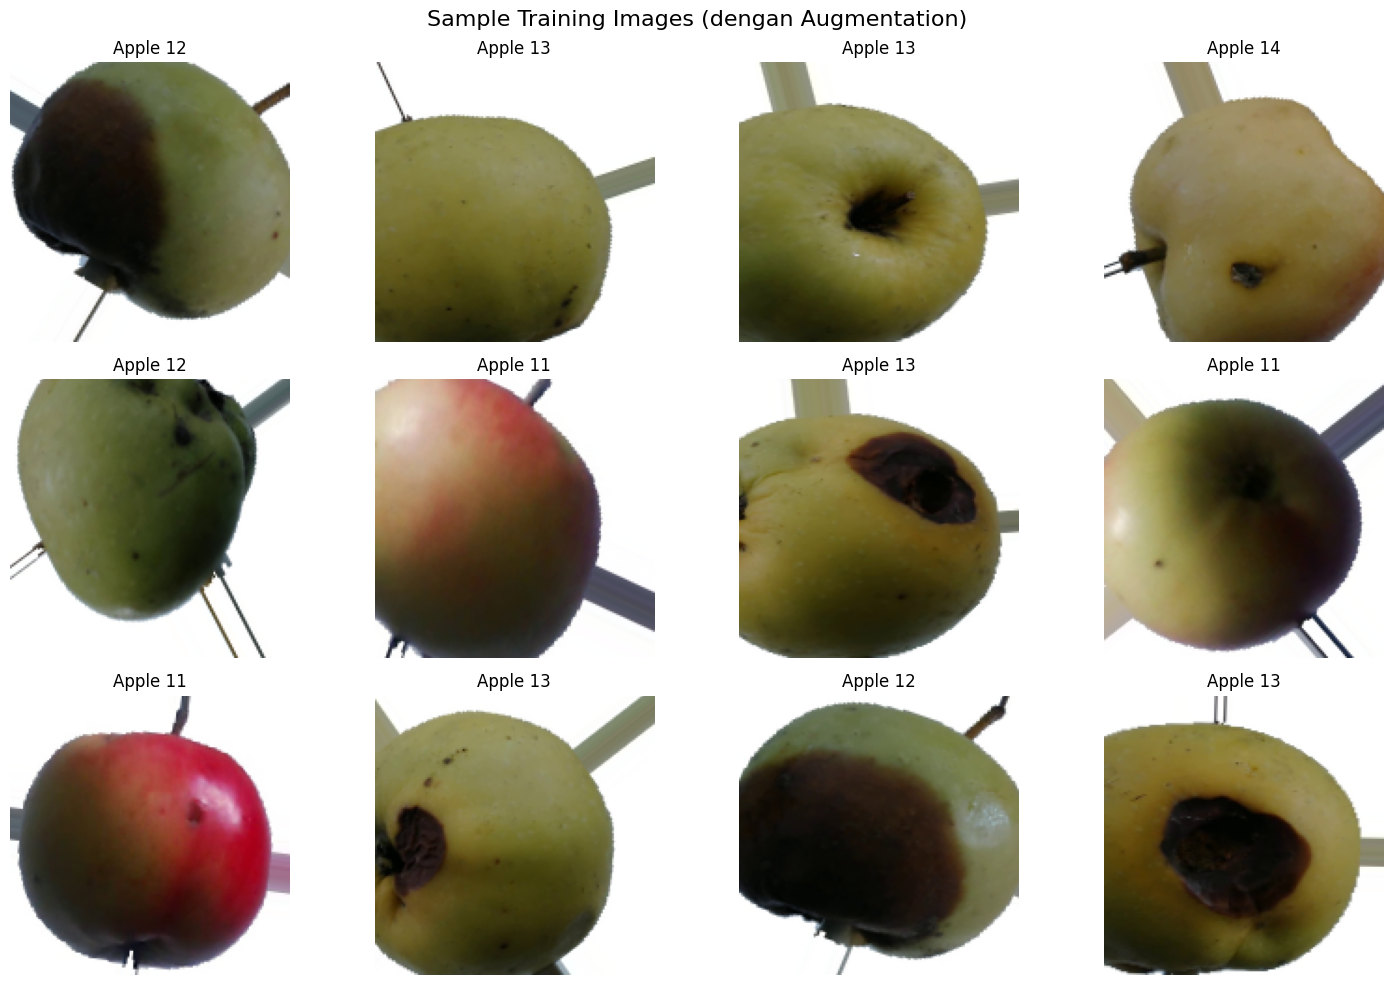

In [16]:
def visualize_samples(generator, title="Sample Images"):
    plt.figure(figsize=(15, 10))
    images, labels_batch = next(generator)
    class_names = list(generator.class_indices.keys())

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        label_idx = np.argmax(labels_batch[i])
        plt.title(class_names[label_idx])
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_samples(train_generator, "Sample Training Images (dengan Augmentation)")

## 8. Membangun Model CNN

In [17]:
print(f"Jumlah Kelas: {NUM_CLASSES}")

# Model Sequential dengan Conv2D dan MaxPooling
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 4
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten dan Dense layers
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Jumlah Kelas: 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Implementasi Callbacks

In [18]:
# Callback 1: Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Callback 2: Model Checkpoint - Simpan dengan format .keras
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Callback 3: Reduce LR on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]
print("✅ Callbacks berhasil dibuat!")

✅ Callbacks berhasil dibuat!


## 10. Training Model

In [19]:
EPOCHS = 50

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training selesai!")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4196 - loss: 1.3396
Epoch 1: val_accuracy improved from -inf to 0.83203, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 396ms/step - accuracy: 0.4233 - loss: 1.3321 - val_accuracy: 0.8320 - val_loss: 0.4224 - learning_rate: 0.0010
Epoch 2/50
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7812 - loss: 0.4568

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.83203
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7812 - loss: 0.4568 - val_accuracy: 0.7617 - val_loss: 0.5828 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7757 - loss: 0.5910
Epoch 3: val_accuracy did not improve from 0.83203
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 268ms/step - accuracy: 0.7765 - loss: 0.5897 - val_accuracy: 0.8125 - val_loss: 0.4211 - learning_rate: 0.0010
Epoch 4/50
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8125 - loss: 0.4908
Epoch 4: val_accuracy improved from 0.83203 to 0.87500, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8125 - loss: 0.4908 - val_accuracy: 0.8750 - val_loss: 0.2918 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9144 - loss: 0.2516
Epoch 5: val_accuracy improved from 0.87500 to 0.97656, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/ste

## 11. Plot Akurasi dan Loss

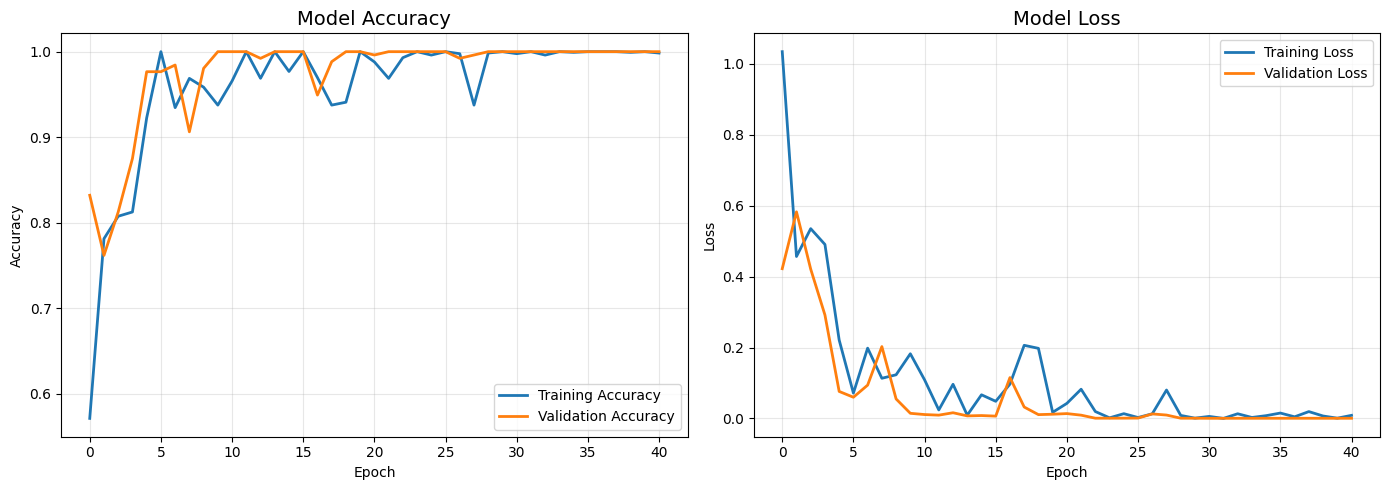


✅ Plot disimpan sebagai 'training_history.png'


In [20]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Plot Loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Plot disimpan sebagai 'training_history.png'")

plot_training_history(history)

## 12. Evaluasi Model

In [21]:
print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)

# Evaluasi Training Set
train_generator.reset()
train_loss, train_accuracy = model.evaluate(train_generator, verbose=0)
print(f"\nTraining Set:")
print(f"  Loss: {train_loss:.4f}")
print(f"  Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Evaluasi Validation Set
validation_generator.reset()
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=0)
print(f"\nValidation Set:")
print(f"  Loss: {val_loss:.4f}")
print(f"  Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Evaluasi Test Set
test_generator.reset()
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f"\nTest Set:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "=" * 50)
if train_accuracy >= 0.85 and test_accuracy >= 0.85:
    print("✅ KRITERIA TERPENUHI: Akurasi >= 85%")
else:
    print("❌ KRITERIA BELUM TERPENUHI: Akurasi < 85%")
print("=" * 50)

EVALUASI MODEL

Training Set:
  Loss: 0.0079
  Accuracy: 0.9977 (99.77%)

Validation Set:
  Loss: 0.0004
  Accuracy: 1.0000 (100.00%)

Test Set:
  Loss: 0.0003
  Accuracy: 1.0000 (100.00%)

✅ KRITERIA TERPENUHI: Akurasi >= 85%


## 13. Confusion Matrix dan Classification Report

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step


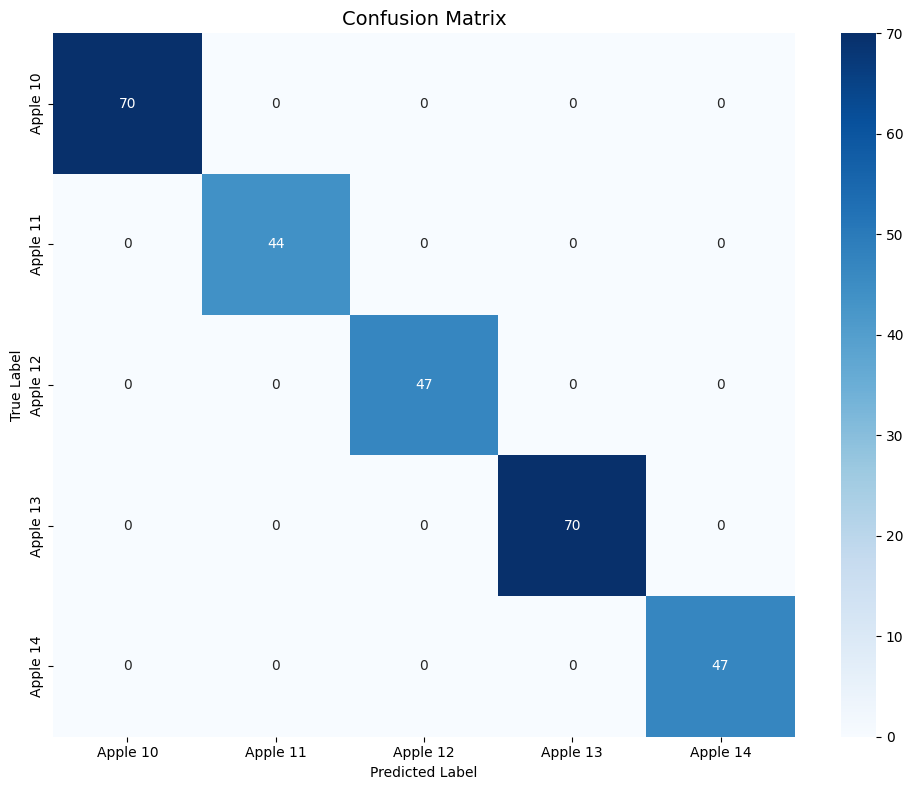


Classification Report:
              precision    recall  f1-score   support

    Apple 10       1.00      1.00      1.00        70
    Apple 11       1.00      1.00      1.00        44
    Apple 12       1.00      1.00      1.00        47
    Apple 13       1.00      1.00      1.00        70
    Apple 14       1.00      1.00      1.00        47

    accuracy                           1.00       278
   macro avg       1.00      1.00      1.00       278
weighted avg       1.00      1.00      1.00       278



In [22]:
# Prediksi
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

## 14. Simpan Model

In [23]:
# ============================================
# SIMPAN MODEL DALAM FORMAT .keras (Native Keras 3)
# ============================================
KERAS_MODEL_PATH = 'model_submission.keras'
model.save(KERAS_MODEL_PATH)
print(f"✅ Model disimpan dalam format .keras: {KERAS_MODEL_PATH}")
print(f"   Ukuran: {os.path.getsize(KERAS_MODEL_PATH) / (1024*1024):.2f} MB")

# ============================================
# SIMPAN MODEL DALAM FORMAT SavedModel (untuk TFLite & TFJS)
# ============================================
SAVED_MODEL_DIR = 'saved_model'
model.export(SAVED_MODEL_DIR)
print(f"\n✅ Model di-export dalam format SavedModel: {SAVED_MODEL_DIR}")

# Lihat isi direktori SavedModel
print("\nIsi direktori SavedModel:")
for root, dirs, files in os.walk(SAVED_MODEL_DIR):
    level = root.replace(SAVED_MODEL_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

✅ Model disimpan dalam format .keras: model_submission.keras
   Ukuran: 39.60 MB
Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139391302290320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302292048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302293392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302291664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302291472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302293584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302294352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302292816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139391302294544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13939130

## 15. Konversi ke TF-Lite

In [24]:
TFLITE_DIR = 'tflite'
os.makedirs(TFLITE_DIR, exist_ok=True)

# Konversi dari SavedModel ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Simpan model TFLite
tflite_model_path = os.path.join(TFLITE_DIR, 'model.tflite')
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Model TF-Lite disimpan di: {tflite_model_path}")
print(f"   Ukuran: {os.path.getsize(tflite_model_path) / (1024*1024):.2f} MB")

# Simpan label.txt
label_path = os.path.join(TFLITE_DIR, 'label.txt')
with open(label_path, 'w') as f:
    for label in labels:
        f.write(f"{label}\n")

print(f"\n✅ Label disimpan di: {label_path}")
print("\nIsi label.txt:")
with open(label_path, 'r') as f:
    print(f.read())

✅ Model TF-Lite disimpan di: tflite/model.tflite
   Ukuran: 3.31 MB

✅ Label disimpan di: tflite/label.txt

Isi label.txt:
Apple 10
Apple 11
Apple 12
Apple 13
Apple 14



## 16. Konversi ke TFJS

In [25]:
# Install tensorflowjs
!pip install tensorflowjs -q

TFJS_DIR = 'tfjs_model'

# Konversi dari SavedModel ke TFJS
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model {SAVED_MODEL_DIR} {TFJS_DIR}

print(f"\n✅ Model TFJS disimpan di: {TFJS_DIR}")

# Lihat isi direktori TFJS
print("\nIsi direktori TFJS:")
for file in os.listdir(TFJS_DIR):
    file_path = os.path.join(TFJS_DIR, file)
    size = os.path.getsize(file_path) / 1024
    print(f"  {file}: {size:.2f} KB")

2026-01-02 04:47:38.822195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767329258.844933   30889 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767329258.853541   30889 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767329258.871403   30889 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767329258.871430   30889 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767329258.871434   30889 computation_placer.cc:177] computation placer alr

## 17. Inference dengan Model .keras

In [26]:
print("=" * 60)
print("INFERENCE MENGGUNAKAN MODEL .keras")
print("=" * 60)

# Load model dari file .keras (Keras 3 native format)
loaded_model = tf.keras.models.load_model(KERAS_MODEL_PATH)
print(f"✅ Model berhasil di-load dari: {KERAS_MODEL_PATH}")

# Fungsi preprocessing
def preprocess_image(image_path, target_size=(150, 150)):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Ambil sample dari test set
test_images = []
for cls in os.listdir(TEST_DIR):
    class_dir = os.path.join(TEST_DIR, cls)
    if os.path.isdir(class_dir):
        images = [img for img in os.listdir(class_dir)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            test_images.append((os.path.join(class_dir, images[0]), cls))

# Inference
print("\nHasil Inference Model .keras:")
print("-" * 60)

correct = 0
total = 0

for img_path, true_label in test_images:
    if os.path.exists(img_path):
        img_array = preprocess_image(img_path)
        predictions = loaded_model.predict(img_array, verbose=0)
        predicted_class = labels[np.argmax(predictions[0])]
        confidence = np.max(predictions[0]) * 100

        is_correct = predicted_class == true_label
        if is_correct:
            correct += 1
        total += 1

        status = "✅" if is_correct else "❌"
        print(f"{status} Gambar: {os.path.basename(img_path)}")
        print(f"   True Label: {true_label}")
        print(f"   Prediksi: {predicted_class}")
        print(f"   Confidence: {confidence:.2f}%")
        print()

print("=" * 60)
print(f"Akurasi Inference: {correct}/{total} ({correct/total*100:.2f}%)")
print("=" * 60)

INFERENCE MENGGUNAKAN MODEL .keras
✅ Model berhasil di-load dari: model_submission.keras

Hasil Inference Model .keras:
------------------------------------------------------------
✅ Gambar: r0_176.jpg
   True Label: Apple 12
   Prediksi: Apple 12
   Confidence: 100.00%

✅ Gambar: r0_278.jpg
   True Label: Apple 13
   Prediksi: Apple 13
   Confidence: 100.00%

✅ Gambar: r0_278.jpg
   True Label: Apple 10
   Prediksi: Apple 10
   Confidence: 100.00%

✅ Gambar: r0_176.jpg
   True Label: Apple 14
   Prediksi: Apple 14
   Confidence: 99.99%

✅ Gambar: r1_92.jpg
   True Label: Apple 11
   Prediksi: Apple 11
   Confidence: 99.99%

Akurasi Inference: 5/5 (100.00%)


## 18. Inference dengan TF-Lite

In [27]:
print("=" * 60)
print("INFERENCE MENGGUNAKAN TF-LITE")
print("=" * 60)

# Load TF-Lite model
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\nInput shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

# Fungsi inference TF-Lite
def tflite_inference(interpreter, image_path, target_size=(150, 150)):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    return output

# Inference
print("\nHasil Inference TF-Lite:")
print("-" * 60)

correct = 0
total = 0

for img_path, true_label in test_images:
    if os.path.exists(img_path):
        predictions = tflite_inference(interpreter, img_path)
        predicted_class = labels[np.argmax(predictions[0])]
        confidence = np.max(predictions[0]) * 100

        is_correct = predicted_class == true_label
        if is_correct:
            correct += 1
        total += 1

        status = "✅" if is_correct else "❌"
        print(f"{status} Gambar: {os.path.basename(img_path)}")
        print(f"   True Label: {true_label}")
        print(f"   Prediksi: {predicted_class}")
        print(f"   Confidence: {confidence:.2f}%")
        print()

print("=" * 60)
print(f"Akurasi Inference TFLite: {correct}/{total} ({correct/total*100:.2f}%)")
print("=" * 60)

INFERENCE MENGGUNAKAN TF-LITE

Input shape: [  1 150 150   3]
Output shape: [1 5]

Hasil Inference TF-Lite:
------------------------------------------------------------
✅ Gambar: r0_176.jpg
   True Label: Apple 12
   Prediksi: Apple 12
   Confidence: 100.00%

✅ Gambar: r0_278.jpg
   True Label: Apple 13
   Prediksi: Apple 13
   Confidence: 100.00%

✅ Gambar: r0_278.jpg
   True Label: Apple 10
   Prediksi: Apple 10
   Confidence: 100.00%

✅ Gambar: r0_176.jpg
   True Label: Apple 14
   Prediksi: Apple 14
   Confidence: 99.99%

✅ Gambar: r1_92.jpg
   True Label: Apple 11
   Prediksi: Apple 11
   Confidence: 99.99%

Akurasi Inference TFLite: 5/5 (100.00%)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 19. Visualisasi Hasil Prediksi

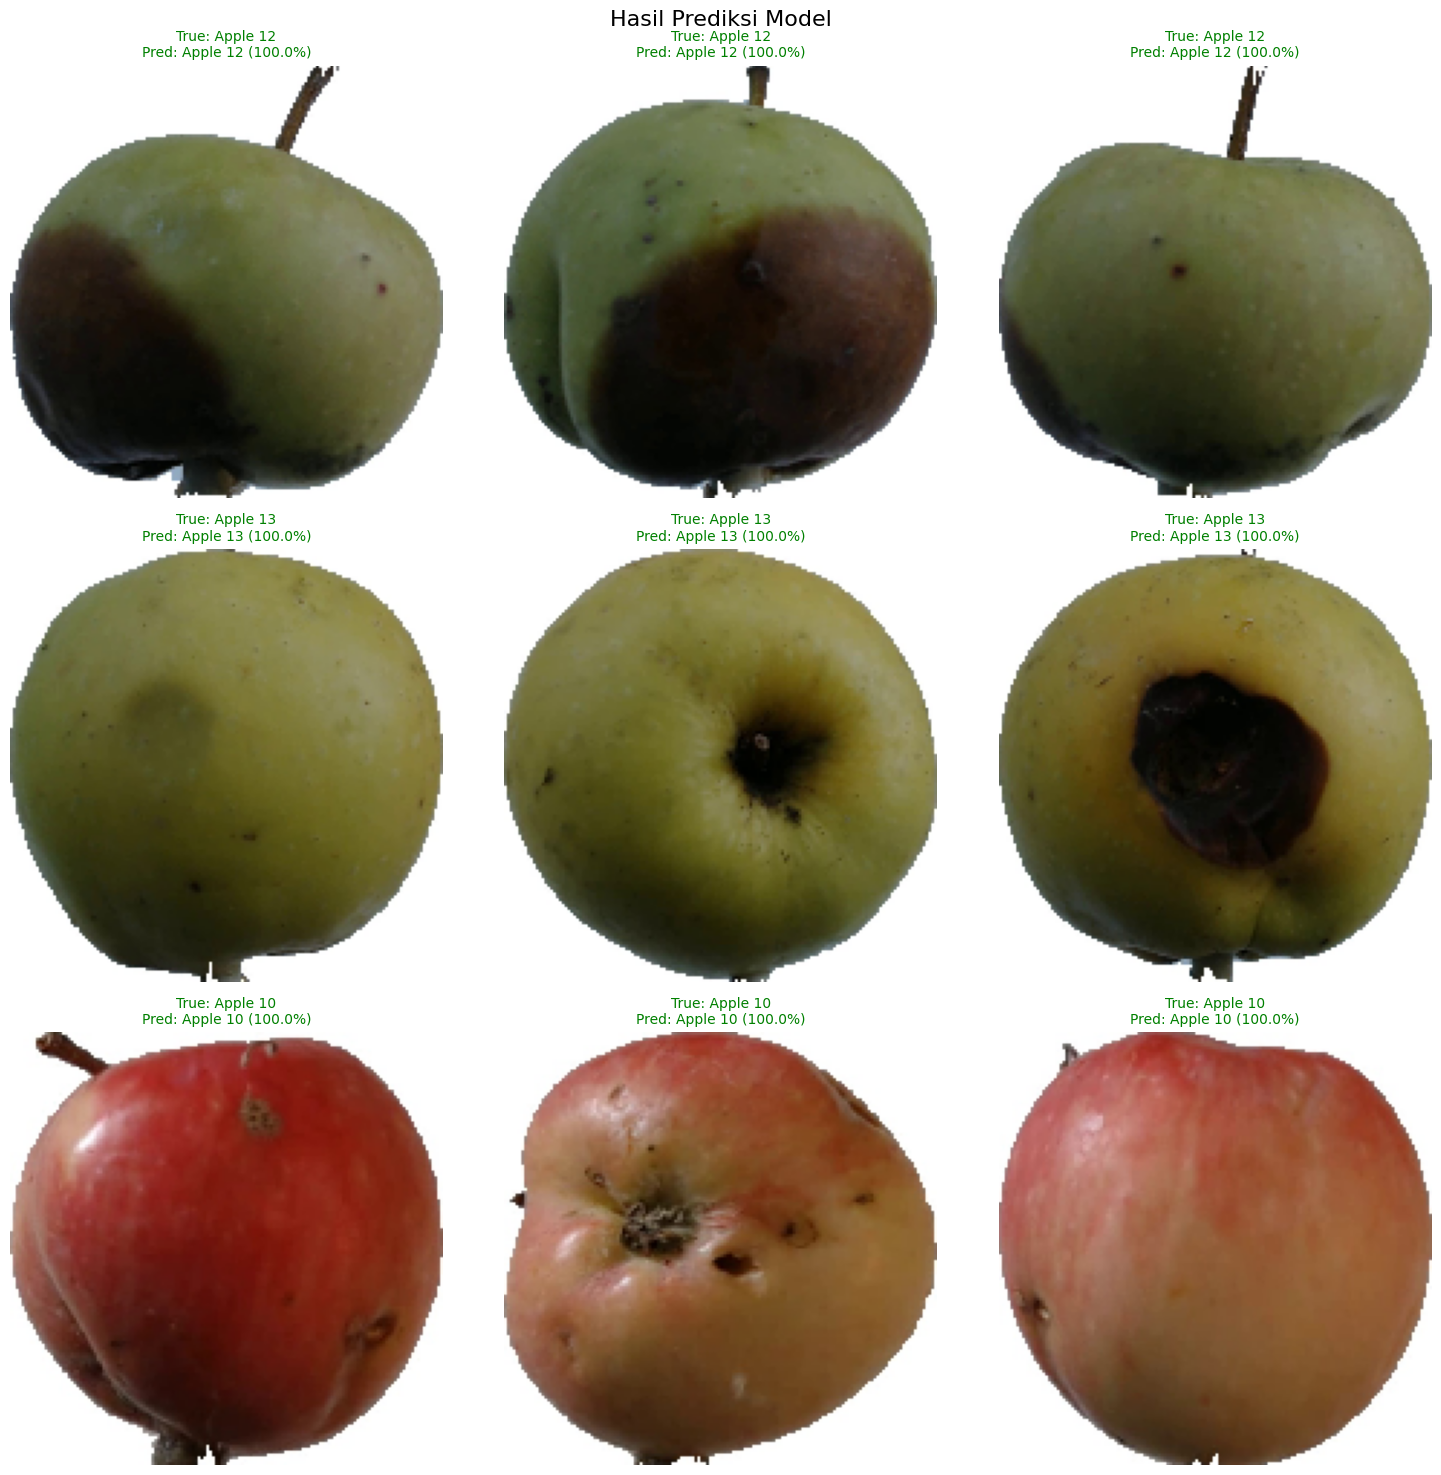

In [28]:
def visualize_predictions(model, test_dir, labels, num_images=9):
    plt.figure(figsize=(15, 15))

    all_images = []
    for cls in os.listdir(test_dir):
        class_dir = os.path.join(test_dir, cls)
        if os.path.isdir(class_dir):
            for img_name in os.listdir(class_dir)[:3]:
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append((os.path.join(class_dir, img_name), cls))

    sample_images = all_images[:num_images]

    for i, (img_path, true_label) in enumerate(sample_images):
        plt.subplot(3, 3, i + 1)

        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
        plt.imshow(img)

        img_array = preprocess_image(img_path)
        predictions = model.predict(img_array, verbose=0)
        predicted_class = labels[np.argmax(predictions[0])]
        confidence = np.max(predictions[0]) * 100

        color = 'green' if predicted_class == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {predicted_class} ({confidence:.1f}%)",
                  color=color, fontsize=10)
        plt.axis('off')

    plt.suptitle('Hasil Prediksi Model', fontsize=16)
    plt.tight_layout()
    plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(loaded_model, TEST_DIR, labels)

## 20. Buat ZIP untuk Submission

In [29]:
# Buat folder submission
submission_dir = 'submission'
os.makedirs(submission_dir, exist_ok=True)

# Copy model .keras
shutil.copy2(KERAS_MODEL_PATH, os.path.join(submission_dir, KERAS_MODEL_PATH))

# Copy SavedModel
if os.path.exists(SAVED_MODEL_DIR):
    shutil.copytree(SAVED_MODEL_DIR, os.path.join(submission_dir, 'saved_model'), dirs_exist_ok=True)

# Copy TFLite
if os.path.exists(TFLITE_DIR):
    shutil.copytree(TFLITE_DIR, os.path.join(submission_dir, 'tflite'), dirs_exist_ok=True)

# Copy TFJS
if os.path.exists(TFJS_DIR):
    shutil.copytree(TFJS_DIR, os.path.join(submission_dir, 'tfjs_model'), dirs_exist_ok=True)

# Buat requirements.txt
with open(os.path.join(submission_dir, 'requirements.txt'), 'w') as f:
    f.write("""tensorflow>=2.15.0
numpy>=1.21.0
matplotlib>=3.5.0
Pillow>=9.0.0
scikit-learn>=1.0.0
seaborn>=0.11.0
tensorflowjs>=4.0.0""")

print("✅ Semua file berhasil dicopy ke folder submission")

# Lihat struktur
print("\nStruktur folder submission:")
for root, dirs, files in os.walk(submission_dir):
    level = root.replace(submission_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

✅ Semua file berhasil dicopy ke folder submission

Struktur folder submission:
submission/
  model_submission.keras
  requirements.txt
  tflite/
    model.tflite
    label.txt
  tfjs_model/
    model.json
    group1-shard1of4.bin
    group1-shard4of4.bin
    group1-shard2of4.bin
    group1-shard3of4.bin
  saved_model/
    saved_model.pb
    fingerprint.pb
    assets/
    variables/
      variables.data-00000-of-00001
      variables.index


In [30]:
# Buat ZIP
shutil.make_archive('submission', 'zip', submission_dir)
print("✅ File submission.zip berhasil dibuat!")
print(f"   Ukuran: {os.path.getsize('submission.zip') / (1024*1024):.2f} MB")

✅ File submission.zip berhasil dibuat!
   Ukuran: 72.77 MB


In [31]:
# Download ZIP
from google.colab import files
files.download('submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 21. Summary

In [32]:
print("=" * 70)
print("SUMMARY PROYEK KLASIFIKASI GAMBAR")
print("=" * 70)

print("\n📊 DATASET:")
print(f"   - Total Gambar: {train_count + val_count + test_count}")
print(f"   - Training: {train_count}")
print(f"   - Validation: {val_count}")
print(f"   - Testing: {test_count}")
print(f"   - Jumlah Kelas: {NUM_CLASSES} ({', '.join(labels)})")

print("\n🏗️ ARSITEKTUR MODEL:")
print(f"   - Model: Sequential")
print(f"   - Layers: Conv2D + MaxPooling2D + Dense")
print(f"   - Total Parameters: {model.count_params():,}")

print("\n📈 PERFORMA MODEL:")
print(f"   - Training Accuracy: {train_accuracy*100:.2f}%")
print(f"   - Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"   - Test Accuracy: {test_accuracy*100:.2f}%")

print("\n💾 MODEL TERSIMPAN:")
print(f"   - Keras (.keras): ✅")
print(f"   - SavedModel: ✅")
print(f"   - TF-Lite: ✅")
print(f"   - TFJS: ✅")

print("\n✅ KRITERIA SUBMISSION:")
print(f"   [{'✓' if train_count + val_count + test_count >= 1000 else '✗'}] Minimal 1000 gambar")
print(f"   [{'✓' if NUM_CLASSES >= 3 else '✗'}] Minimal 3 kelas")
print(f"   [✓] Dataset dibagi: Train, Validation, Test")
print(f"   [✓] Model Sequential dengan Conv2D dan Pooling")
print(f"   [{'✓' if train_accuracy >= 0.85 and test_accuracy >= 0.85 else '✗'}] Akurasi >= 85%")
print(f"   [✓] Plot akurasi dan loss")
print(f"   [✓] Model: SavedModel, TF-Lite, TFJS")
print(f"   [✓] Implementasi Callback")
print(f"   [✓] Inference dengan bukti")

print("\n" + "=" * 70)
print("🎉 PROYEK SELESAI!")
print("=" * 70)

SUMMARY PROYEK KLASIFIKASI GAMBAR

📊 DATASET:
   - Total Gambar: 1837
   - Training: 1284
   - Validation: 275
   - Testing: 278
   - Jumlah Kelas: 5 (Apple 10, Apple 11, Apple 12, Apple 13, Apple 14)

🏗️ ARSITEKTUR MODEL:
   - Model: Sequential
   - Layers: Conv2D + MaxPooling2D + Dense
   - Total Parameters: 3,455,173

📈 PERFORMA MODEL:
   - Training Accuracy: 99.77%
   - Validation Accuracy: 100.00%
   - Test Accuracy: 100.00%

💾 MODEL TERSIMPAN:
   - Keras (.keras): ✅
   - SavedModel: ✅
   - TF-Lite: ✅
   - TFJS: ✅

✅ KRITERIA SUBMISSION:
   [✓] Minimal 1000 gambar
   [✓] Minimal 3 kelas
   [✓] Dataset dibagi: Train, Validation, Test
   [✓] Model Sequential dengan Conv2D dan Pooling
   [✓] Akurasi >= 85%
   [✓] Plot akurasi dan loss
   [✓] Model: SavedModel, TF-Lite, TFJS
   [✓] Implementasi Callback
   [✓] Inference dengan bukti

🎉 PROYEK SELESAI!
